# Getting started

This guide introduces the main single-GPU workflows in jz-fmm through a small satellite example. By the end, you will know how to:

- evaluate forces with the fast multipole method (FMM),
- evolve particle distributions through time,
- run a simulation with snapshots,
- include contributions from an external potential, and
- solve a small satellite-reconstruction problem with gradient descent through a differentiable simulation.

Multi-GPU execution will be discussed in a separate guide.

## Verify the installation

From the repository root, run:

```bash
python hello_world.py
```

This evolves roughly one million particles spelling `JZ-FMM` and then reverses the integration. The simulation is run backwards in the end to show that the integer-lattice drift-kick-drift integrator and deterministic force evaluation recover the initial state exactly. Use `python hello_world.py --only-forward` to omit the rewind. Using `--movie` will render a movie instead of displaying it live, in case you are working remotely.

In [1]:
from dataclasses import replace
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import jzfmm

print(jax.devices())

[CudaDevice(id=0)]


## Create a particle distribution

Throughout the guide, we represent a satellite as a Gaussian cloud of particles. The helper below creates Gaussian positions and velocities, then optionally shifts their center and bulk velocity. This deliberately simple Gaussian blob is **not an equilibrium model**. It will relax and change shape even in isolation. A realistic satellite would instead be initialized from an equilibrium distribution function.

The default units are kpc, km/s, and solar masses, but they can be adapted. For a single GPU, `Particles` only needs positions, velocities, and masses; its multi-GPU bookkeeping fields like `num` and `num_total` can remain unset.

In [2]:
def make_satellite(nparticles=1_000_000, center=(0.0, 0.0, 0.0),
                   bulk_velocity=(0.0, 0.0, 0.0), seed=7):
    pos = 0.5 * jax.random.normal(jax.random.key(seed), (nparticles, 3))
    vel = 35.0 * jax.random.normal(jax.random.key(seed + 1), (nparticles, 3))
    return jzfmm.data.Particles(
        pos=pos + jnp.asarray(center),
        vel=vel + jnp.asarray(bulk_velocity),
        mass=jnp.full(nparticles, 1.0e9 / nparticles),
    )

## Evaluate forces with the FMM

We begin by calculating the satellite's self-gravity directly with the FMM. `FMMConfig` controls the force calculation, while `UnitConfig` supplies the gravitational constant in the selected unit system.

Using JAX's just-in-time (JIT) compilation is key for performance. Since it can be cumbersome to distinguish cleanly between static and dynamic arguments, we provide convenient wrappers through the `.jit` attribute on many functions. The first call compiles the calculation for the given argument shapes and configuration; subsequent calls reuse the compiled program.

JAX dispatches work asynchronously, so `block_until_ready()` is needed for an accurate benchmark. We use the first evaluation only for compilation and then time ten force calculations.

In [3]:
satellite = make_satellite()
cfg_fmm = jzfmm.FMMConfig()
units = jzfmm.UnitConfig()

loc = jzfmm.fmm.fast_multipole_method.jit(satellite, cfg_fmm=cfg_fmm, G=units.G())
loc.values.block_until_ready()

benchmark_start = time.perf_counter()
for _ in range(10):
    loc = jzfmm.fmm.fast_multipole_method.jit(satellite, cfg_fmm=cfg_fmm, G=units.G())
    loc.values.block_until_ready()

mean_time = (time.perf_counter() - benchmark_start) / 10
print(f"Mean time for 1,000,000 particles: {mean_time:.3f} s")

Mean time for 1,000,000 particles: 0.044 s


The returned `loc` object is a `LocalExpansion`. It stores the local Taylor expansion of the potential evaluated at every particle. `loc.force()` extracts the corresponding force vectors. Here a tiny visualization of some of the forces:

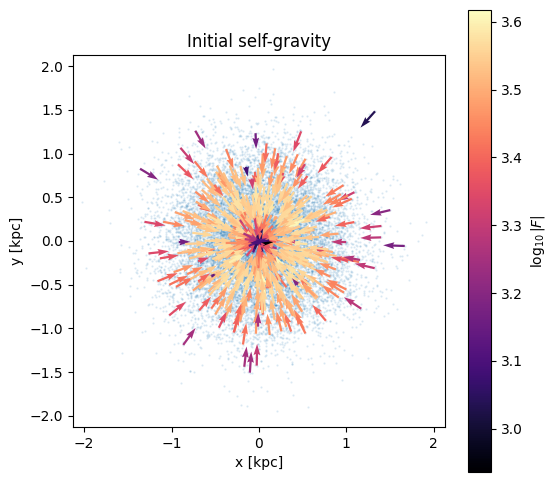

In [4]:
force = loc.force()
force_norm = jnp.linalg.norm(force, axis=-1)
force_direction = force / jnp.maximum(force_norm[:, None], 1.0e-20)
sample = slice(None, None, 2048)
limit = float(jnp.max(jnp.abs(satellite.pos[::64, :2]))) * 1.05

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(satellite.pos[::64, 0], satellite.pos[::64, 1], s=0.3, alpha=0.15)
arrows = ax.quiver(
    satellite.pos[sample, 0], satellite.pos[sample, 1],
    force_direction[sample, 0], force_direction[sample, 1],
    jnp.log10(force_norm[sample]), cmap="magma", angles="xy", scale_units="xy",
    scale=4.0, width=0.006,
)
fig.colorbar(arrows, ax=ax, label=r"$\log_{10}|F|$")
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="x [kpc]", ylabel="y [kpc]",
       aspect="equal", title="Initial self-gravity")
plt.show()

## Evolve a particle distribution

A default `SimConfig` combines the FMM force solver with a drift-kick-drift integrator. The array `ts` contains the initial time and every integration endpoint, while `simulate` returns the final particle state.

In [ ]:
satellite_initial = make_satellite()
cfg_evolution = jzfmm.SimConfig()
satellite_final = jzfmm.time_integration.simulate.jit(
    satellite_initial, ts=jnp.linspace(0.0, 0.01, 41), cfg=cfg_evolution
)

The 3 lines above are really everything that is needed for running a simulation. However, depending on your application, you may be interested in some of the features below.

## Snapshots and External Potentials

Below you can see how we set up an external Hernquist potential via the config data class. You could easily define your own potentials and they will automatically be differentiated to get forces. 

Further, you can see how `simulate_with_outputs` can be used as a generator for particle outputs. Usually you should process them one by one to not explode the memory (see e.g. `hello_world.py`), but below we materialize a list that contains all outputs at once for simplicity. `simulate_with_outputs` should not be jitted, but it calls a jitted simulation function internally.

In [6]:
satellite_orbit = make_satellite(center=(25.0, 0.0, 0.0), bulk_velocity=(0.0, 100.0, 0.0))
cfg_orbit = jzfmm.SimConfig()
cfg_orbit.force.kernel.softening = 0.2
cfg_orbit.external_potential = jzfmm.external_potential.HernquistPotential(
    a=10.0, mass=1.0e11
)

orbit_snapshots = list(jzfmm.time_integration.simulate_with_outputs(
    satellite_orbit, tend=0.8, nout=6, steps_per_output=20, cfg=cfg_orbit
))

[time_integration.py:358] Compiling jitted simulation...
[time_integration.py:371] Compilation done after 2.18s
[time_integration.py:385] Reached output 1 (1.44s for 20 steps)
[time_integration.py:385] Reached output 2 (1.35s for 20 steps)
[time_integration.py:385] Reached output 3 (1.06s for 20 steps)
[time_integration.py:385] Reached output 4 (1.19s for 20 steps)
[time_integration.py:385] Reached output 5 (0.96s for 20 steps)
[time_integration.py:385] Reached output 6 (1.24s for 20 steps)
[time_integration.py:389] Total simulation time: 9.44s for 120 steps


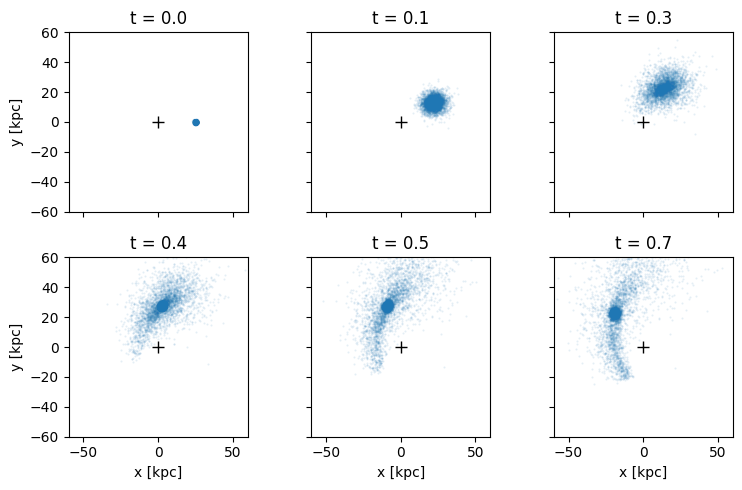

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True)
for ax, (snapshot_time, state) in zip(axes.flat, orbit_snapshots):
    ax.scatter(state.pos[::64, 0], state.pos[::64, 1], s=0.3, alpha=0.1)
    ax.plot(0.0, 0.0, marker="+", color="black", markersize=8)
    ax.set(title=f"t = {float(snapshot_time):.1f}", aspect="equal")
    ax.set_xlim(-60,60)
    ax.set_ylim(-60,60)
for ax in axes[-1]:
    ax.set_xlabel("x [kpc]")
for ax in axes[:, 0]:
    ax.set_ylabel("y [kpc]")
plt.tight_layout()
plt.show()

## Reconstructing a satellite with differentiable simulations

We finish with a small inverse problem based on the disrupting satellite above. Its initial center-of-mass position is now unknown, while its initial center-of-mass velocity is assumed to be known. We generate a target from the same Hernquist-orbit setup and use gradient descent to recover the initial position vector.

A differentiable simulation treats the final particle distribution as a function of its initial conditions. A loss is defined based on the final state. Reverse-mode differentiation propagates its gradient back through every integration step to the initial position.

![Gradient propagation through a reversible simulation](../docs/_static/sim_backprop.svg)

jz-fmm reconstructs earlier particle states during the backward pass instead of retaining the full forward trajectory. We recommend `DKDLatticeConfig` for this workflow because its integer phase-space updates are perfectly reversible. Its `dx` and `dv` parameters are the position and velocity lattice spacings: choose them substantially smaller than the smallest changes that need to be resolved, while ensuring that the full position and velocity range fits into the selected integer dtype. Smaller spacings improve quantization resolution but reduce the available dynamic range. `int64` provides considerably more range than `int32`.

Since we need to run many simulations here, we use a smaller number of 200,000 particles to keep things interactive. Note also that evaluating the gradient of a simulation takes more or less three times as long as just running the simulation, for the reasons mentioned above.

In [8]:
target_com_pos = jnp.array([25.0, 0.0, 0.0])
target_com_vel = jnp.array([0.0, 100.0, 0.0])
ts_reconstruction = jnp.linspace(0.0, 0.8, 21)
satellite_base = make_satellite(nparticles=200_000)
cfg_reconstruction = jzfmm.SimConfig()
cfg_reconstruction.force.kernel.softening = 0.5
cfg_reconstruction.integrator = jzfmm.DKDLatticeConfig(dx=1.0e-5, dv=1.0e-5)
cfg_reconstruction.external_potential = jzfmm.external_potential.HernquistPotential(
    a=10.0, mass=1.0e11
)

target_initial = replace(
    satellite_base,
    pos=satellite_base.pos + target_com_pos,
    vel=satellite_base.vel + target_com_vel,
)
target_final = jzfmm.time_integration.simulate.jit(
    target_initial, ts=ts_reconstruction, cfg=cfg_reconstruction
)

For each proposed COM position vector, we evolve a new initial state and compare its final distribution with the target using the maximum mean discrepancy (MMD) with a distance kernel. This loss is zero if the distributions are identical and grows approximately linearly at large distances. Its diagonal terms require `remove_self_interaction=False`.

In [9]:
cfg_loss = jzfmm.FMMConfig(
    kernel=jzfmm.SoftenedDistanceKernel(softening=1.0),
    remove_self_interaction=False,
)

def reconstruction_loss(com_pos):
    trial_initial = replace(
        satellite_base,
        pos=satellite_base.pos + com_pos,
        vel=satellite_base.vel + target_com_vel,
    )
    trial_final = jzfmm.time_integration.simulate(
        trial_initial, ts=ts_reconstruction, cfg=cfg_reconstruction
    )
    return jzfmm.loss.maximum_mean_discrepancy(
        trial_final, target_final, cfg_fmm=cfg_loss
    )


loss_and_grad = jax.jit(jax.value_and_grad(reconstruction_loss, argnums=(0, )))

Note that we can differentiate this custom loss function with `jax.value_and_grad` because all used functions support it. In particular the simulate function implements the custom VJP rule that we have mentioned above. Note that we should wrap our gradient function in `jax.jit` for performance.

Here, we only optimize the initial position of the object. It is also possible to recover the velocity in these types of problem setups (see the article), but it requires notable numerical care and we want to focus on the code interface here.

In [10]:
com_pos = jnp.array([70.0, 12., -30.])
com_pos_history = []
loss_history = []

print(f"Target COM position:    {target_com_pos}")

for iteration in range(51):
    loss_value, (gradient_pos, ) = loss_and_grad(com_pos)
    com_pos_history.append(com_pos)
    loss_history.append(float(loss_value))
    if iteration % 5 == 0:
        print(f"{iteration:2d}: loss={float(loss_value):.4g}, com_pos={com_pos}")
    com_pos = com_pos - 2.0 * gradient_pos * jnp.exp(-iteration/20.) 


print(f"Recovered COM position: {com_pos}")

Target COM position:    [25.  0.  0.]
 0: loss=182.2, com_pos=[ 70.  12. -30.]
 5: loss=110.5, com_pos=[ 49.893353   -1.0784497 -22.555832 ]
10: loss=19.34, com_pos=[ 28.526016 -10.602095 -12.753241]
15: loss=7.04, com_pos=[25.986996  -8.2861    -6.1037536]
20: loss=3.072, com_pos=[26.151875  -5.749845  -2.8131852]
25: loss=1.399, com_pos=[25.942873  -3.9522347 -1.2609113]
30: loss=0.6897, com_pos=[25.725378  -2.7701433 -0.6006299]
35: loss=0.3762, com_pos=[25.55297    -2.0362887  -0.31989875]
40: loss=0.2284, com_pos=[25.44269   -1.5794615 -0.1923656]
45: loss=0.1531, com_pos=[25.36702    -1.2893038  -0.12879054]
50: loss=0.1116, com_pos=[25.316004   -1.0984068  -0.09415147]
Recovered COM position: [25.30786   -1.0684593 -0.0892236]


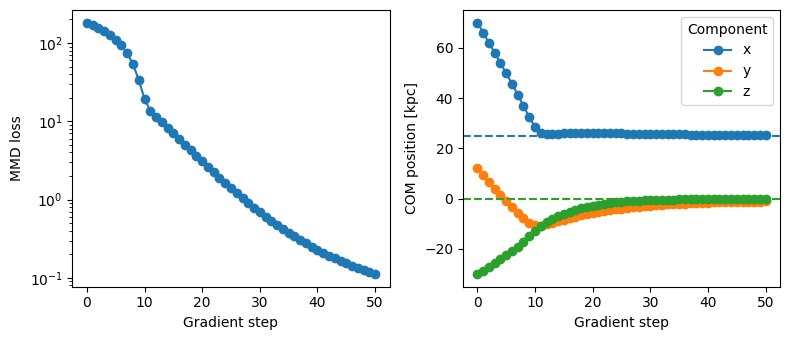

In [11]:
com_pos_history = jnp.stack(com_pos_history)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].plot(loss_history, marker="o")
axes[0].set(xlabel="Gradient step", ylabel="MMD loss", yscale="log")
for component, label in enumerate(("x", "y", "z")):
    axes[1].plot(com_pos_history[:, component], marker="o", label=label)
    axes[1].axhline(target_com_pos[component], color=f"C{component}", linestyle="--")
axes[1].set(xlabel="Gradient step", ylabel="COM position [kpc]")
axes[1].legend(title="Component")
plt.tight_layout()
plt.show()

The reconstruction can be refined further by continuing the optimization, but the gradient already brings us close to the target quite rapidly. Below you can see the optimization path. Remember that every step runs its own simulation followed by a backward pass and gradient propagation.

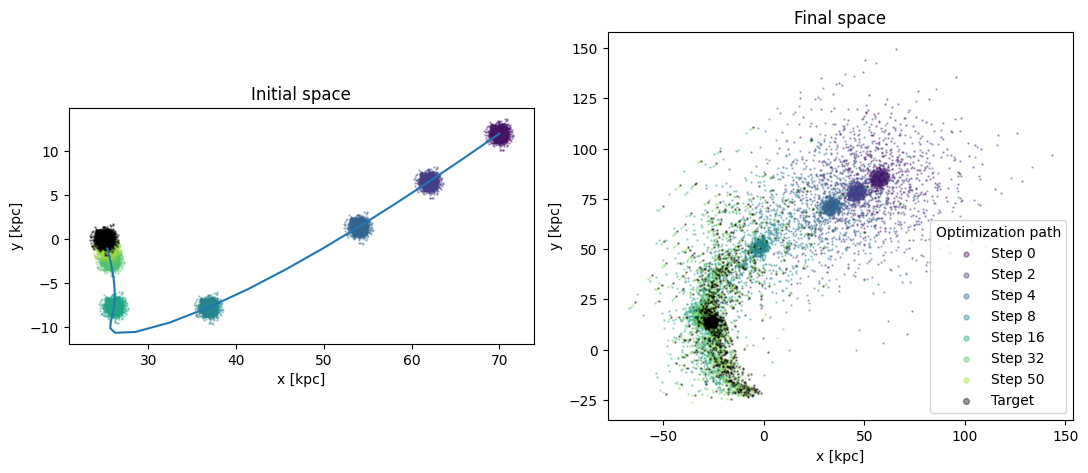

In [12]:
history_indices = [0, 2, 4, 8, 16, 32, 50]
reconstruction_states = []

for index in history_indices:
    initial = replace(
        satellite_base,
        pos=satellite_base.pos + com_pos_history[index],
        vel=satellite_base.vel + target_com_vel,
    )
    final = jzfmm.time_integration.simulate.jit(
        initial, ts=ts_reconstruction, cfg=cfg_reconstruction
    )
    reconstruction_states.append((initial, final))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = plt.cm.viridis(jnp.linspace(0.05, 0.85, len(history_indices)))
axes[0].plot(com_pos_history[:,0], com_pos_history[:,1])
for color, index, (initial, final) in zip(
    colors, history_indices, reconstruction_states
):
    label = f"Step {index}"
    axes[0].scatter(initial.pos[::100, 0], initial.pos[::100, 1], s=0.5, alpha=0.4,
                    color=color, label=label)
    axes[1].scatter(final.pos[::100, 0], final.pos[::100, 1], s=0.5, alpha=0.4,
                    color=color, label=label)
axes[0].scatter(target_initial.pos[::100, 0], target_initial.pos[::100, 1], s=0.7,
                alpha=0.4, color="black", label="Target")
axes[1].scatter(target_final.pos[::100, 0], target_final.pos[::100, 1], s=0.7,
                alpha=0.4, color="black", label="Target")
for ax, title in zip(axes, ("Initial space", "Final space")):
    ax.set(title=title, xlabel="x [kpc]", ylabel="y [kpc]", aspect="equal")
axes[1].legend(markerscale=5, title="Optimization path")
plt.tight_layout()
plt.show()

## Where to go next

The reconstruction above is intentionally simplified. A realistic application should use more particles and time steps, a physically motivated equilibrium profile for the satellite (or even better: cosmological initial conditions), an observationally appropriate loss function, possibly many more degrees of freedom and a better optimization method. As discussed in the article, optimization can be quite tricky in these loss landscapes and needs to be investigated carefully in future work.

The [API reference](https://jstuecker.github.io/jzfmm/api.html) describes the available kernels, integrators, external potentials, and compatibility helpers. Multi-GPU execution will be covered in a separate guide.